## The cosine similarity based on Morgan Fingerprints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### load precomputed Morgan Fingerprints

In [2]:
df = pd.read_parquet('molecular_descriptors_raw_models_.parquet')

In [3]:
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_[nH]:c:c,ChyLine_l2-4_c:[nH]:cC,ChyLine_l2-4_c:[nH]:c:c,ChyLine_l2-4_[nH]:c:c:c,ChyLine_l2-4_[nH]:cC,ChyLine_l2-4_c:[nH]:c,ChyLine_l2-4_[nH]:cCC,ChyLine_l2-4_[nH]:cCO,ChyLine_l2-4_[nH]:c,ChyLine_l2-4_c:cOc
0,22.437500,6.008125,3.437500,7.375000,155.889356,88.574589,1.629168,6.108350,4.059896,7.544068,...,0,0,0,0,0,0,0,0,0,0
1,33.379310,6.189617,3.689655,8.124308,154.312811,135.992311,1.819416,6.359666,4.300949,7.785859,...,0,0,0,0,0,0,0,0,0,0
2,33.379310,6.189617,3.689655,8.124308,154.312811,135.992311,1.819416,6.359666,4.300949,7.785859,...,0,0,0,0,0,0,0,0,0,0
3,23.448276,6.080345,3.517241,7.862069,154.890681,92.692779,1.670871,6.182231,4.315134,7.601129,...,0,0,0,0,0,0,0,0,0,0
4,27.612903,6.626287,3.774194,10.838710,157.711443,109.522793,1.629260,6.688823,7.699821,8.084495,...,0,0,0,0,0,0,0,0,0,0
5,27.612903,6.626287,3.774194,10.838710,157.711443,109.522793,1.629260,6.688823,7.699821,8.084495,...,0,0,0,0,0,0,0,0,0,0
6,27.612903,6.626287,3.774194,10.838710,157.711443,109.522793,1.629260,6.688823,7.699821,8.084495,...,0,0,0,0,0,0,0,0,0,0
7,65.655172,6.172331,3.689655,8.105766,153.326826,312.818060,1.976316,6.317459,4.277603,7.726767,...,0,0,0,0,0,0,0,0,0,0
8,22.437500,6.008125,3.437500,7.375000,155.889356,88.574589,1.629168,6.108350,4.059896,7.544068,...,0,0,0,0,0,0,0,0,0,0
9,20.526316,6.139474,3.052632,6.421053,163.559978,80.628710,1.329202,6.188668,4.557018,7.719562,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Remove columns that are entirely zeros
df_unchanged = df_unchanged.loc[:, (df_unchanged != 0).any(axis=0)]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6   \
0   1.000000  0.926924  0.956402  0.938666  0.948372  0.935286  0.919290   
1   0.926924  1.000000  0.947025  0.970659  0.932928  0.948061  0.972331   
2   0.956402  0.947025  1.000000  0.946229  0.965581  0.944460  0.932998   
3   0.938666  0.970659  0.946229  1.000000  0.938451  0.960700  0.962664   
4   0.948372  0.932928  0.965581  0.938451  1.000000  0.963676  0.944989   
5   0.935286  0.948061  0.944460  0.960700  0.963676  1.000000  0.960562   
6   0.919290  0.972331  0.932998  0.962664  0.944989  0.960562  1.000000   
7   0.962270  0.940403  0.973422  0.958517  0.965581  0.951206  0.932998   
8   0.984388  0.920007  0.937804  0.932659  0.930001  0.928194  0.912467   
9   0.544413  0.495540  0.497184  0.492860  0.495434  0.508826  0.493833   
10  0.944839  0.961099  0.959003  0.964989  0.950654  0.957576  0.952789   
11  0.934684  0.974013  0.948424  0.966671  0.940175  0.952289  0.965535   
12  0.938800

In [5]:
df_final

,C_FP_1,C_FP_9,C_FP_28,C_FP_39,C_FP_49,C_FP_51,C_FP_63,C_FP_80,C_FP_84,C_FP_91,...,C_FP_1970,C_FP_1991,C_FP_1994,C_FP_1999,C_FP_2016,C_FP_2021,C_FP_2027,C_FP_2033,C_FP_2038,C_FP_2043
0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.4238
Maximal similarity between any two rows: 0.9844


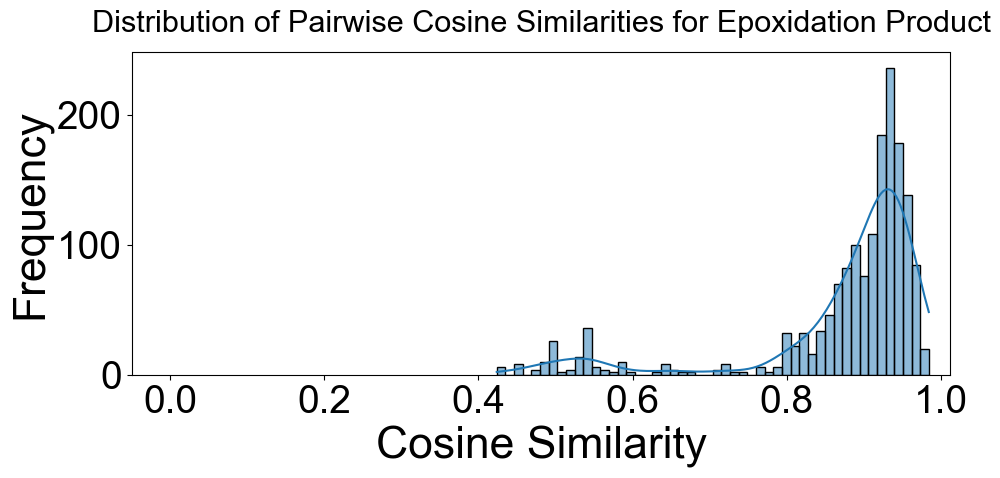

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for Epoxidation Product', fontsize=22, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_II.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()